In [ ]:
import numpy as np
import tqdm
import matplotlib.pyplot as plt

# =========================
# Basic quaternion utilities
# =========================
# Convention: q = [w, x, y, z], w is scalar part

def normalize_quat(q: np.ndarray) -> np.ndarray:
    """Normalize a quaternion to unit norm."""
    q = np.asarray(q, dtype=float)
    return q / np.linalg.norm(q)


def quat_conj(q: np.ndarray) -> np.ndarray:
    """Quaternion conjugate."""
    w, x, y, z = q
    return np.array([w, -x, -y, -z], dtype=float)


def quat_multiply(q1: np.ndarray, q2: np.ndarray) -> np.ndarray:
    """Quaternion product q = q1 ⊗ q2."""
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2

    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    return np.array([w, x, y, z], dtype=float)


def random_unit_quaternion() -> np.ndarray:
    """Sample a random unit quaternion (uniform on SO(3))."""
    # Using method based on normal distribution
    v = np.random.randn(4)
    return normalize_quat(v)


# ========================================
# Left/right quaternion multiplication matrices
# ========================================

def L_matrix(q: np.ndarray) -> np.ndarray:
    """
    Left multiplication matrix L(q) such that:
        q ⊗ p = L(q) @ p
    """
    w, x, y, z = q
    return np.array([
        [ w, -x, -y, -z],
        [ x,  w, -z,  y],
        [ y,  z,  w, -x],
        [ z, -y,  x,  w]
    ], dtype=float)


def R_matrix(q: np.ndarray) -> np.ndarray:
    """
    Right multiplication matrix R(q) such that:
        p ⊗ q = R(q) @ p
    """
    w, x, y, z = q
    return np.array([
        [ w, -x, -y, -z],
        [ x,  w,  z, -y],
        [ y, -z,  w,  x],
        [ z,  y, -x,  w]
    ], dtype=float)


# ===========================================
# Generate synthetic quaternion hand-eye data
# ===========================================

def generate_hand_eye_quat_pairs(num_pairs: int,
                                 q_X: np.ndarray,
                                 rot_noise_std: float = 0.0):
    """
    Generate synthetic rotation-only hand–eye measurements (quaternions).

    Hand–eye equation in quaternion form:
        q_Ai ⊗ q_X = q_X ⊗ q_Bi

    We fix q_X (ground-truth hand–eye rotation), then:
        - sample random q_Ai
        - define noise-free q_Bi = q_X^{-1} ⊗ q_Ai ⊗ q_X
        - optionally perturb q_Ai and q_Bi by small random rotations.

    Parameters
    ----------
    num_pairs : int
        Number of motion pairs (A_i, B_i).
    q_X : array-like, shape (4,)
        Ground-truth hand–eye rotation quaternion.
    rot_noise_std : float
        Standard deviation of small-angle noise (radians) applied to A and B.

    Returns
    -------
    q_As : ndarray, shape (num_pairs, 4)
        Relative motion rotations on "A" side (e.g., robot).
    q_Bs : ndarray, shape (num_pairs, 4)
        Relative motion rotations on "B" side (e.g., camera).
    """
    q_X = normalize_quat(q_X)
    q_X_inv = quat_conj(q_X)  # since q_X is unit, inverse == conjugate

    q_As = np.zeros((num_pairs, 4))
    q_Bs = np.zeros((num_pairs, 4))

    for i in range(num_pairs):
        # 1) random A motion
        q_A = random_unit_quaternion()

        # 2) corresponding noise-free B motion from hand-eye constraint
        #    q_A ⊗ q_X = q_X ⊗ q_B  ⇒  q_B = q_X^{-1} ⊗ q_A ⊗ q_X
        q_B = quat_multiply(q_X_inv, quat_multiply(q_A, q_X))

        # 3) Optionally add small isotropic rotation noise
        if rot_noise_std > 0.0:
            def small_noise_quat(std):
                # small random axis, small angle ~ N(0, std^2)
                axis = np.random.randn(3)
                axis /= np.linalg.norm(axis)
                angle = np.random.randn() * std
                half =  angle
                w = np.cos(half)
                xyz = axis * np.sin(half)
                return normalize_quat(np.concatenate([[w], xyz]))

            q_noise_A = small_noise_quat(rot_noise_std)
            q_noise_B = small_noise_quat(rot_noise_std)

            q_A = quat_multiply(q_noise_A, q_A)
            q_B = quat_multiply(q_noise_B, q_B)

        q_As[i] = normalize_quat(q_A)
        q_Bs[i] = normalize_quat(q_B)

    return q_As, q_Bs


# ==================================
# Build Z matrix for null-space solve
# ==================================

def build_Z_from_quat_pairs(q_As: np.ndarray,
                            q_Bs: np.ndarray) -> np.ndarray:
    """
    Construct the linear constraint matrix Z for quaternion hand–eye calibration.

    For each pair (q_Ai, q_Bi), the hand–eye constraint is:
        q_Ai ⊗ q_X = q_X ⊗ q_Bi

    Using left/right multiplication matrices:
        L(q_Ai) q_X = R(q_Bi) q_X
        (L(q_Ai) - R(q_Bi)) q_X = 0

    Each pair contributes a 4x4 matrix; stacking all gives:
        Z q_X = 0,  Z ∈ R^{4N x 4},  q_X is in the null space of Z.

    Parameters
    ----------
    q_As : ndarray, shape (N, 4)
        Quaternion motions on A side.
    q_Bs : ndarray, shape (N, 4)
        Quaternion motions on B side.

    Returns
    -------
    Z : ndarray, shape (4N, 4)
        Stacked constraint matrix for null-space estimation of q_X.
    """
    assert q_As.shape == q_Bs.shape
    N = q_As.shape[0]

    Z_blocks = []
    for i in range(N):
        q_A = normalize_quat(q_As[i])
        q_B = normalize_quat(q_Bs[i])

        L_A = L_matrix(q_A)   # 4x4
        R_B = R_matrix(q_B)   # 4x4

        Z_i = L_A - R_B       # 4x4 block
        Z_blocks.append(Z_i)

    Z = np.vstack(Z_blocks)   # shape: (4N, 4)
    return Z


# ==============================================
# Example: full pipeline and SVD-based estimation
# ==============================================


sigma = 1e-2  # 1 degree noise (optional)
q_X_true = normalize_quat(np.random.randn(4)) 
numCases= 2000
numPops= 2000
popRisks= []
popRisks2= []
popRisksAna= []
Xs= []
stardIdx= 4
endIdx= 30
for j in tqdm.tqdm(range(5, 60)):
    T = j
    # sigma= 1e-1*10**(-4+j/(endIdx-stardIdx)*4)
    Xs.append(T)
    popRisk= 0
    # popRisk2= 0
    q_As_pop, q_Bs_pop = generate_hand_eye_quat_pairs(numPops, q_X_true, rot_noise_std= sigma)
    Z_pop = build_Z_from_quat_pairs(q_As_pop, q_Bs_pop)
    # Z_pop = Z_pop+np.random.randn(Z_pop.shape[0], Z_pop.shape[1])*sigma
    for i in range(numCases):
        # 2) Generate synthetic motion pairs (measurements)
        q_As, q_Bs = generate_hand_eye_quat_pairs(T, q_X_true, rot_noise_std=sigma)
        # 3) Build Z matrix from measurements
        Z = build_Z_from_quat_pairs(q_As, q_Bs)
        # Z = Z+np.random.randn(Z.shape[0], Z.shape[1])*sigma
        # 4) Estimate q_X from the null space of Z via SVD
        U, S, Vt = np.linalg.svd(Z)
        q_X_est = Vt[-1, :]  # right singular vector with smallest singular value
        q_X_est = normalize_quat(q_X_est)
        if q_X_est[0]*q_X_true[0]<0:
            q_X_est= -q_X_est
        delta= (q_X_est-q_X_true)[:, None]
        popRisk+= np.mean(np.square(Z_pop@delta))
        # popRisk2+= np.mean(np.square(Z_pop@q_X_est))
    popRisks.append(popRisk/numCases)
    # popRisks2.append(popRisk2/numCases-np.square(sigma)/8)
    popRisksAna.append(((np.square(sigma/2.5)*3/(T*4-3-1))))



100%|██████████| 55/55 [03:10<00:00,  3.46s/it]


In [23]:
popRisksAna= []
for j in tqdm.tqdm(range(5, 60)):
    T = j
    popRisksAna.append(((np.square(sigma/1.25)*3/(T*4-3-1))))

100%|██████████| 55/55 [00:00<?, ?it/s]


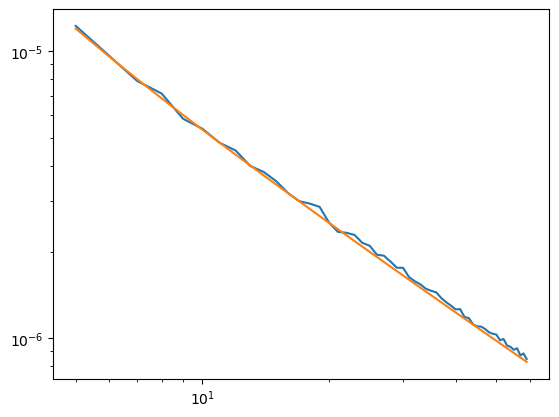

In [24]:
import matplotlib.pyplot as plt
# plt.plot(popRisks2[:])
plt.plot(Xs, popRisks[:])
plt.plot(Xs, popRisksAna[:])
plt.yscale("log")
plt.xscale("log")

In [2]:
import numpy as np

print(np.cos(np.pi))

-1.0
